# Bibliotecas Utilizadas

In [8]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Carregamento dos Dados e Filtragem pelo Gênero Pop

In [9]:
df = pd.read_csv('spotify-tracks-dataset.csv')
df_pop = df[df['track_genre'] == 'pop'].copy()

# Remoção de Identificadores e Metadados

In [10]:
cols_drop = ['Unnamed: 0', 'Unnamed: 0.1', 'track_id', 'album_name', 'track_name', 'artists', 'track_genre']
df_pop = df_pop.drop(columns=[c for c in cols_drop if c in df_pop.columns]).dropna().drop_duplicates()

# Engenharia de Atributos (Target e Explicito)

In [11]:
df_pop['is_hit'] = (df_pop['popularity'] > 70).astype(int)
df_pop = df_pop.drop(columns=['popularity'])
df_pop['explicit'] = df_pop['explicit'].astype(int)

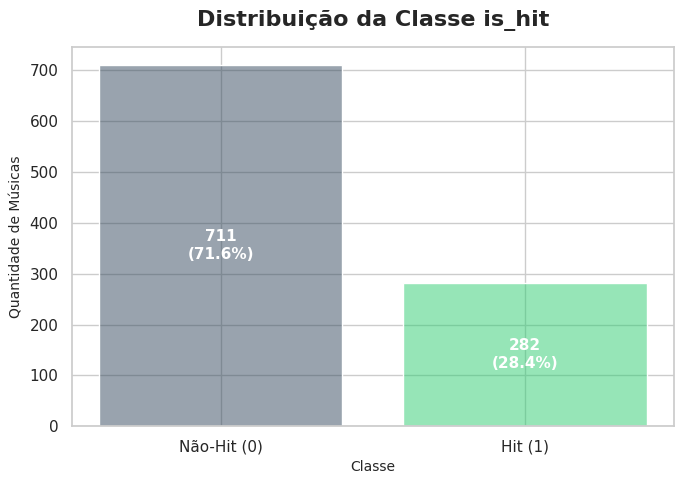

In [23]:
# Configurar o estilo do gráfico
sns.set_theme(style="whitegrid")
plt.figure(figsize=(7, 5))

# Criação do histograma
ax = sns.histplot(
    data=df_pop,
    x='is_hit',
    discrete=True,
    shrink=0.8,
    hue='is_hit',
    palette={0: '#34495e', 1: '#2ecc71'},
    legend=False
)

# Personalização
plt.title('Distribuição da Classe is_hit', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Classe', fontsize=10)
plt.ylabel('Quantidade de Músicas', fontsize=10)
plt.xticks([0, 1], ['Não-Hit (0)', 'Hit (1)'])

# Adicionar anotações os valores dentro das barras do histograma
total_amostras = len(df_pop)
for p in ax.patches:
    altura = p.get_height()
    if altura > 0:
        percentagem = (altura / total_amostras) * 100
        ax.annotate(
            f'{int(altura)}\n({percentagem:.1f}%)',
            (p.get_x() + p.get_width() / 2., altura / 2),
            ha='center',
            va='center',
            color='white',
            fontweight='bold',
            fontsize=11)

plt.tight_layout()
plt.show()

# Escalonamento das Variáveis de Áudio

In [13]:
colunas_audio = [
    'duration_ms', 'danceability', 'energy', 'key', 'loudness',
    'mode', 'speechiness', 'acousticness', 'instrumentalness',
    'liveness', 'valence', 'tempo', 'time_signature'
]
scaler = StandardScaler()
df_pop[colunas_audio] = scaler.fit_transform(df_pop[colunas_audio]).round(4)

# Exportação do dataset já tratado

In [14]:
df_pop.to_csv('spotify-pop_tracks-dataset(limpo).csv', index=False)